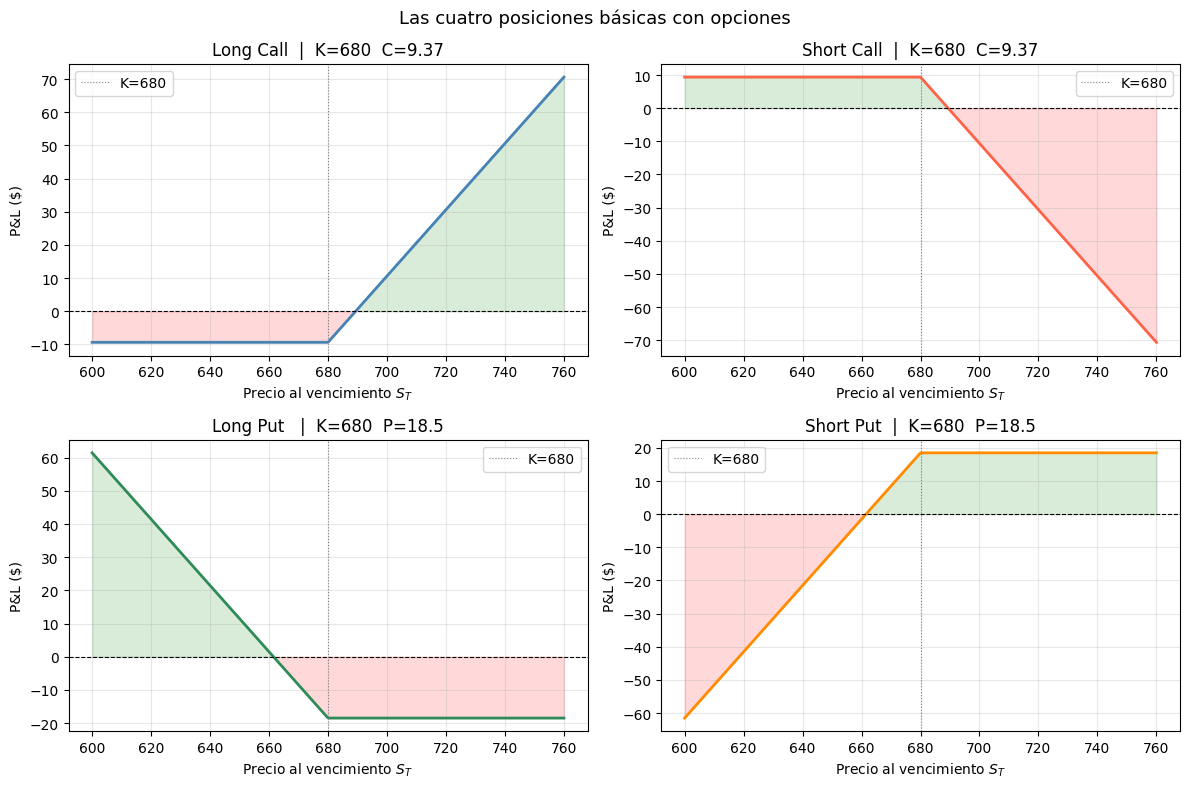

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

S_range = np.linspace(600, 760, 500)   # rango de precios al vencimiento
K = 680
C = 9.37    # prima del call
P = 18.50   # prima del put

# --- Payoffs brutos ---
call_long_bruto  =  np.maximum(S_range - K, 0)
call_short_bruto = -np.maximum(S_range - K, 0)
put_long_bruto   =  np.maximum(K - S_range, 0)
put_short_bruto  = -np.maximum(K - S_range, 0)

# --- P&L neto ---
pnl_call_long  = call_long_bruto  - C
pnl_call_short = call_short_bruto + C
pnl_put_long   = put_long_bruto   - P
pnl_put_short  = put_short_bruto  + P

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    (axes[0,0], pnl_call_long,  f'Long Call  |  K={K}  C={C}',  'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call  |  K={K}  C={C}', 'tomato'),
    (axes[1,0], pnl_put_long,   f'Long Put   |  K={K}  P={P}',  'seagreen'),
    (axes[1,1], pnl_put_short,  f'Short Put  |  K={K}  P={P}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(S_range, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Las cuatro posiciones básicas con opciones', fontsize=13)
plt.tight_layout()
plt.show()

In [2]:
#funcion generica patra cualquier estrategia 

def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,6))
    plt.plot(S_range, pnl, label='PnL')

    if S0 is not None:
        plt.axvline(S0, linestyle='--', label=f'S0={S0}')

    if K_lines:
        for K, label in K_lines:
            plt.axvline(K, linestyle=':', alpha=0.7)
    
    plt.axhline(0, color='black')
    plt.title(titulo)
    plt.legend()
    plt.grid()
    plt.show()

## Butterfly Spread

Prima neta pagada : $3.76
Ganancia máxima   : $16.24  (si ST =680)
Pérdida máxima    : $-3.76
Break-even inf.   : $663.76  |  sup.: $696.24


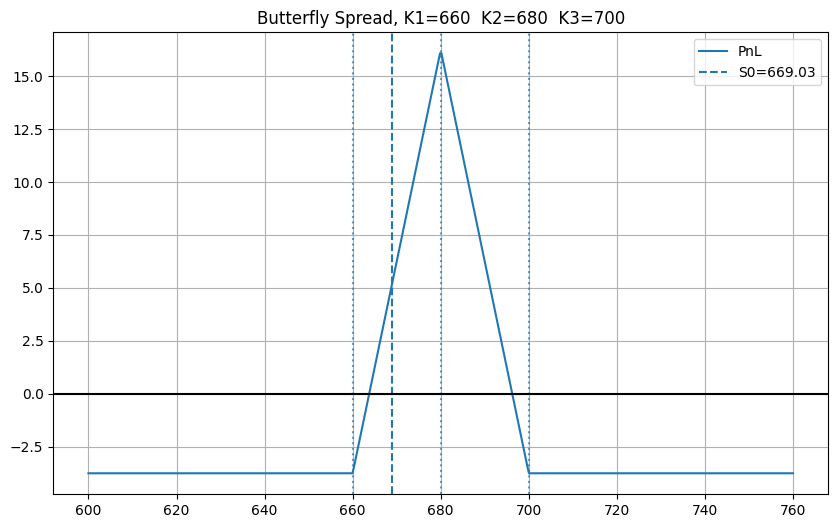

In [10]:
import numpy as np
S_range = np.linspace(600, 760, 500)
S0 = 669.03

K1, K2, K3 = 660, 680, 700
C1, C2, C3 = 18.00, 9.37, 4.50

legs_butterfly = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -2},
    {'tipo': 'call', 'K': K3, 'prima': C3, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_butterfly)
prima_neta = C1 - 2*C2 + C3

print(f"Prima neta pagada : ${prima_neta:.2f}")
print(f"Ganancia máxima   : ${(K2-K1)-prima_neta:.2f}  (si ST ={K2})")
print(f"Pérdida máxima    : ${-prima_neta:.2f}")
print(f"Break-even inf.   : ${K1+prima_neta:.2f}  |  sup.: ${K3-prima_neta:.2f}")

graficar_estrategia(S_range, pnl, f'Butterfly Spread, K1={K1}  K2={K2}  K3={K3}',
                    S0=S0, K_lines=[(K1,f'{K1}'),(K2,f'{K2}'),(K3,f'{K3}')])

In [7]:
def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,6))
    plt.plot(S_range, pnl, label='PnL')

    if S0 is not None:
        plt.axvline(S0, linestyle='--', label=f'S0={S0}')

    if K_lines:
        for K, label in K_lines:
            plt.axvline(K, linestyle=':', alpha=0.7)
    
    plt.axhline(0, color='black')
    plt.title(titulo)
    plt.legend()
    plt.grid()
    plt.show()

## Iron Condor

Prima cobrada     : $9.60  (ganancia máxima)
Pérdida máxima    : $10.40
Zona de ganancia  : [660,700]


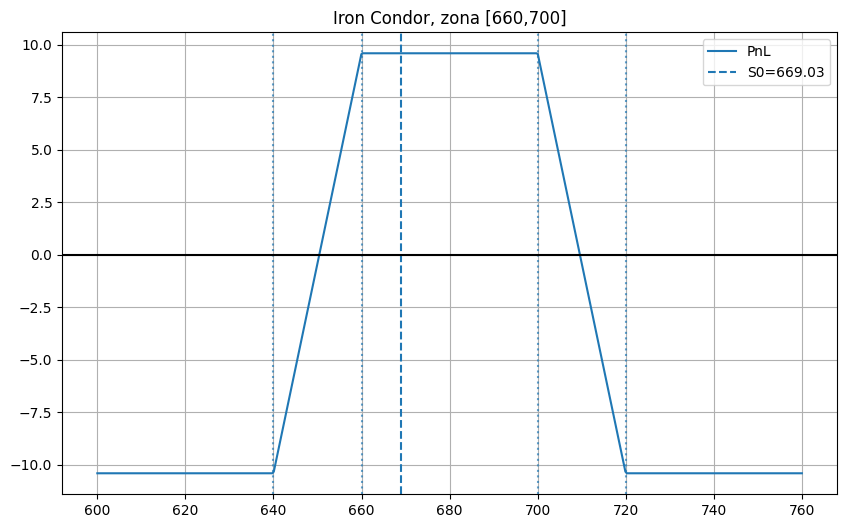

In [8]:
K_pl, K_ps = 640, 660     # put leg: long K_pl, short K_ps
K_cs, K_cl = 700, 720     # call leg: short K_cs, long K_cl
P_l, P_s   = 5.50, 11.20
C_s, C_l   = 6.80, 2.90

legs_condor = [
    {'tipo': 'put',  'K': K_pl, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put',  'K': K_ps, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_condor)
prima_cobrada = (P_s - P_l) + (C_s - C_l)
perdida_max   = (K_ps - K_pl) - prima_cobrada

print(f"Prima cobrada     : ${prima_cobrada:.2f}  (ganancia máxima)")
print(f"Pérdida máxima    : ${perdida_max:.2f}")
print(f"Zona de ganancia  : [{K_ps},{K_cs}]")

graficar_estrategia(S_range, pnl,
                    f'Iron Condor, zona [{K_ps},{K_cs}]', S0=S0,
                    K_lines=[(K_pl,f'{K_pl}'),(K_ps,f'{K_ps}'),
                             (K_cs,f'{K_cs}'),(K_cl,f'{K_cl}')])

##  Covered Call

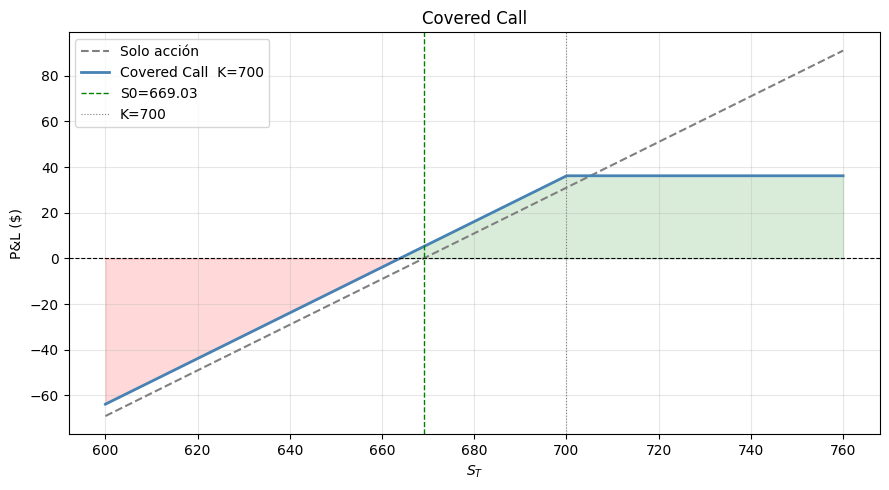

Ganancia máxima : $36.17  (si ST ≥700)
Break-even      : $663.83


In [5]:
K_cc, C_cc = 700, 5.20
pnl_accion  = S_range - S0
pnl_covered = pnl_accion + (-np.maximum(S_range - K_cc, 0) + C_cc)

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,  color='gray',      linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_covered, color='steelblue', linewidth=2,
         label=f'Covered Call  K={K_cc}')
plt.axhline(0,    color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0,   color='green', linewidth=1.0, linestyle='--', label=f'S0={S0}')
plt.axvline(K_cc, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_cc}')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered>0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered<0), alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title('Covered Call'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Ganancia máxima : ${K_cc - S0 + C_cc:.2f}  (si ST ≥{K_cc})")
print(f"Break-even      : ${S0 - C_cc:.2f}")

## Protective Put

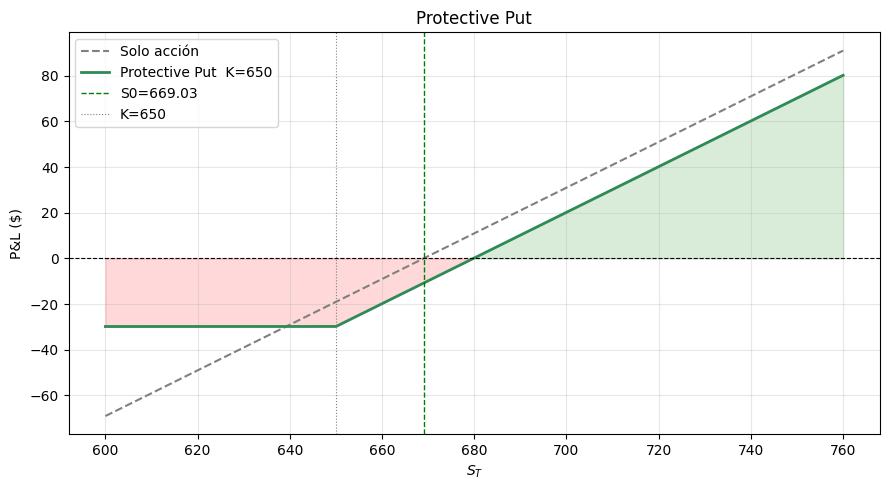

Pérdida máxima : $-29.83  (si ST ≤650)
Break-even     : $679.83


In [6]:
K_pp, P_pp = 650, 10.80
pnl_protective = pnl_accion + (np.maximum(K_pp - S_range, 0) - P_pp)

plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,     color='gray',    linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_protective, color='seagreen', linewidth=2,
         label=f'Protective Put  K={K_pp}')
plt.axhline(0,    color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0,   color='green', linewidth=1.0, linestyle='--', label=f'S0={S0}')
plt.axvline(K_pp, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_pp}')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective>0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective<0), alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title('Protective Put'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Pérdida máxima : ${-(S0 - K_pp + P_pp):.2f}  (si ST ≤{K_pp})")
print(f"Break-even     : ${S0 + P_pp:.2f}")

In [22]:
data = [
    {
        "Estrategia": "Butterfly Call",
        "Prima": prima_neta,
        "Ganancia Máx": (K2 - K1) - prima_neta,
        "Pérdida Máx": -prima_neta,
        "Break-even": f"{K1 + prima_neta:.2f} / {K3 - prima_neta:.2f}"
    },
    {
        "Estrategia": "Iron Condor",
        "Prima": prima_cobrada,
        "Ganancia Máx": prima_cobrada,
        "Pérdida Máx": perdida_max,
        "Break-even": f"{K_ps - prima_cobrada:.2f} / {K_cs + prima_cobrada:.2f}"
    },
    {
        "Estrategia": "Covered Call",
        "Prima": C_cc,
        "Ganancia Máx": K_cc - S0 + C_cc,
        "Pérdida Máx": "Ilimitada ↓",
        "Break-even": f"{S0 - C_cc:.2f}"
    },
    {
        "Estrategia": "Protective Put",
        "Prima": -P_pp,
        "Ganancia Máx": "Ilimitada ↑",
        "Pérdida Máx": -(S0 - K_pp + P_pp),
        "Break-even": f"{S0 + P_pp:.2f}"
    }
]

data

[{'Estrategia': 'Butterfly Call',
  'Prima': 3.7600000000000016,
  'Ganancia Máx': 16.24,
  'Pérdida Máx': -3.7600000000000016,
  'Break-even': '663.76 / 696.24'},
 {'Estrategia': 'Iron Condor',
  'Prima': 9.6,
  'Ganancia Máx': 9.6,
  'Pérdida Máx': 10.4,
  'Break-even': '650.40 / 709.60'},
 {'Estrategia': 'Covered Call',
  'Prima': 5.2,
  'Ganancia Máx': 36.17000000000003,
  'Pérdida Máx': 'Ilimitada ↓',
  'Break-even': '663.83'},
 {'Estrategia': 'Protective Put',
  'Prima': -10.8,
  'Ganancia Máx': 'Ilimitada ↑',
  'Pérdida Máx': -29.829999999999973,
  'Break-even': '679.83'}]

In [ ]:
##

## conslusiones y preguntas 

Con S0 en 669, la mejor posicionada es el iron condor, porque el precio ya está dentro de su rango de ganancia (660–700). La visión de mercado sería que el precio se mantenga estable, sin movimientos fuertes.
No, el iron condor no es sin riesgo. Aunque cobras prima al inicio, puedes perder dinero si el precio se mueve mucho. El peor escenario ocurre cuando el precio cae por debajo de 640 o sube por encima de 720. La pérdida máxima es 10.4.



Con IV alta (35%), es mejor vender un iron condor. Esto se debe a que tiene vega negativa (se beneficia si baja la volatilidad) y además ganas con el paso del tiempo (theta positiva). Un straddle perdería valor si la IV baja.



Un inversionista acepta limitar la ganancia en un covered call porque quiere generar ingresos extra con las primas y porque no espera que el precio suba demasiado. También le ayuda a reducir un poco el riesgo si el precio baja.


El protective put es parecido a un seguro porque pagas una prima para protegerte de pérdidas grandes y tiene una duración. La diferencia es que si no ocurre el evento negativo, pierdes la prima, aunque en opciones puedes cerrar la posición antes. El strike funciona como una especie de nivel de protección similar a un deducible.
El butterfly es más adecuado cuando esperas que el precio termine muy cerca de un nivel específico, mientras que el iron condor funciona mejor cuando esperas un rango más amplio. El butterfly requiere mayor precisión porque su zona de ganancia es mucho más estrecha.


Si compras un butterfly y la IV cae 5 puntos sin que el precio se mueva, el valor de tu posición baja. Esto pasa porque el butterfly tiene vega negativa, así que pierde valor cuando baja la volatilidad.